In [1]:
import torch
torch.autograd.set_grad_enabled(False)

# Inspect ADE20k Segmentation Dataset

In [2]:
import os


root_dir = "datasets/ADEChallengeData2016/ADEChallengeData2016"
images_dir = os.path.join(root_dir, "images")
annotations_dir = os.path.join(root_dir, "annotations")

images_train_dir = os.path.join(images_dir, "training")
annotations_train_dir = os.path.join(annotations_dir, "training")
images_val_dir = os.path.join(images_dir, "validation")
annotations_val_dir = os.path.join(annotations_dir, "validation")

training_images = os.listdir(images_train_dir)
validation_images = os.listdir(images_val_dir)

print(len(training_images), len(validation_images))

20210 2000


In [3]:
import os
from typing import Callable, Optional

from PIL import Image
from torch.utils.data import Dataset
from torchvision.transforms import (
    Compose, Resize, ToTensor, Normalize, PILToTensor, InterpolationMode
)

class ADE20KDataset(Dataset):
    """
    images_dir: folder with RGB *.jpg files
    masks_dir : folder with 8-bit *.png masks (same filename stem)
    """

    def __init__(
        self,
        split: str = "train",
        img_transform : Optional[Callable] = None,
        mask_transform: Optional[Callable] = None,
    ):
        root_dir = "datasets/ADEChallengeData2016/ADEChallengeData2016"
        images_dir = os.path.join(root_dir, "images")
        annotations_dir = os.path.join(root_dir, "annotations")
        if split == "train":
            images_dir = os.path.join(images_dir, "training")
            annotations_dir = os.path.join(annotations_dir, "training")
        elif split == "val":
            images_dir = os.path.join(images_dir, "validation")
            annotations_dir = os.path.join(annotations_dir, "validation")
        else:
            raise ValueError(f"Unknown split: {split}")
        self.images_dir  = Path(images_dir)
        self.masks_dir   = Path(annotations_dir)
        if img_transform is None:
            img_transform = Compose([
                Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
                ToTensor(),
                Normalize(mean=[0.485, 0.456, 0.406],
                          std =[0.229, 0.224, 0.225]),
            ])
        self.img_tf  = img_transform
        if mask_transform is None:
            mask_transform = Compose([
                Resize((256, 256), interpolation=InterpolationMode.NEAREST),
                PILToTensor(),  # keeps uint8 [0‒255]
            ])
        self.mask_tf = mask_transform

        self.image_files = sorted(p for p in self.images_dir.glob("*.jpg"))
        if not self.image_files:
            raise RuntimeError(f"No .jpg files in {self.images_dir}")

        # verify every image has a mask
        self.mask_files = []
        for p in self.image_files:
            m = self.masks_dir / (p.stem + ".png")
            if not m.exists():
                raise FileNotFoundError(f"Missing mask for {p.name}")
            self.mask_files.append(m)

    def __len__(self) -> int:
        return len(self.image_files)

    def __getitem__(self, idx: int):
        img  = Image.open(self.image_files[idx]).convert("RGB")
        mask = Image.open(self.mask_files[idx])  # uint8 grayscale

        if self.img_tf:
            img = self.img_tf(img)
        if self.mask_tf:
            mask = self.mask_tf(mask)

        # squeeze the single channel and cast to long (N, H, W)   → (H, W)
        mask = mask.squeeze(0).long()     # → (H, W), values in {0,1,…,150,255}

        # remap in-place:
        #
        #   raw 1–150 → 0–149
        #   raw 0 or >150 → 255 (ignore_index)
        #
        num_classes  = 150
        ignore_index = 255

        # start with all ignored
        out = torch.full_like(mask, ignore_index)

        # select valid ADE20K IDs
        valid = (mask >= 1) & (mask <= num_classes)
        out[valid] = mask[valid] - 1


        return img, out


# Define the transformations
IMG_SIZE = (256, 256)

img_transform = Compose([
    Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406],
              std =[0.229, 0.224, 0.225]),
])

mask_transform = Compose([
    Resize(IMG_SIZE, interpolation=InterpolationMode.NEAREST),
    PILToTensor(),          # keeps uint8 [0‒255]
])


/tmp/ipykernel_249172/739232174.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow((view2.reshape(C, H*W)[:, indices] * flags[None, :]).reshape(view2.shape).permute(1, 2, 0))


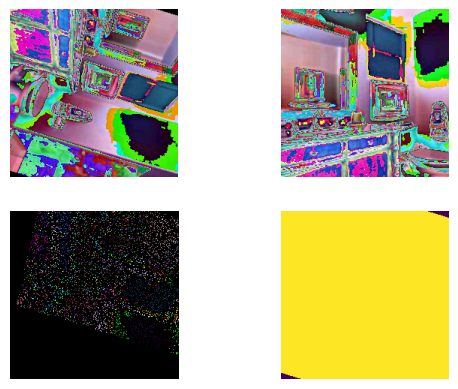

In [4]:
from pathlib import Path

import torch
from torch.utils.data import Dataset
import torchvision.transforms as T

from oxels.transforms import PerspectiveTransform


class ADE20KBackboneDataset(Dataset):
    default_augmentations = T.Compose([
        T.ToPILImage(),
        T.ColorJitter(brightness=0.3, hue=(-0.1, 0.1), saturation=0.3),
        T.RandomAutocontrast(p=0.1),
        T.RandomApply([T.GaussianBlur(kernel_size=7, sigma=(1.0, 3.0))], p=0.1),
        T.RandomPosterize(5, p=0.1),
        T.RandomEqualize(p=0.1),
        T.RandomGrayscale(p=0.05),
        T.ToTensor(),
    ])

    def __init__(
        self,
        split: str = "train",
        w: int = 256,
        h: int = 256,
        frac_keep: float = 0.125,
        augmentations=default_augmentations,
        img_transform=None,
    ):
        super().__init__()
        self.split = split
        self.dataset = ADE20KDataset(self.split, img_transform=img_transform)
        self.perspective_transform = PerspectiveTransform(w=w, h=h, frac_keep=frac_keep)
        self.augmentations = augmentations

    def __getitem__(self, item):
        with torch.device("cpu"):
            rgb, segmentation = self.dataset[item]
        rgb = rgb.numpy()
        rgb = rgb.transpose(1, 2, 0)

        # this needs channels last
        view1, view2, permutation, flags, mask1, mask2 = self.perspective_transform.get_views_and_permutation(rgb)

        view1 = view1.transpose(2, 0, 1)
        view2 = view2.transpose(2, 0, 1)

        with torch.device("cpu"):
            view1 = torch.from_numpy(view1).float()
            view2 = torch.from_numpy(view2).float()

        view1 = self.augmentations(view1)
        view2 = self.augmentations(view2)

        return view1, view2, permutation, flags, mask1, mask2

    def __len__(self):
        return len(self.dataset)


dataset = ADE20KBackboneDataset(
    h=224,
    w=224,
    split="train",
)

view1, view2, indices, flags, mask1, mask2 = dataset[6]
C, H, W = view1.shape
import matplotlib.pyplot as plt
plt.subplot(221)
plt.imshow(view1.permute(1, 2, 0))
plt.axis("off")
plt.subplot(222)
plt.imshow(view2.permute(1, 2, 0))
plt.axis("off")
plt.subplot(223)
plt.imshow((view2.reshape(C, H*W)[:, indices] * flags[None, :]).reshape(view2.shape).permute(1, 2, 0))
plt.axis("off")
plt.subplot(224)
plt.imshow(mask1.reshape(view1.permute(1,2,0).shape[:2]))
plt.axis("off")
plt.show()

# Backbone Model

In [5]:
"""
from collections.abc import Sequence
import os
from torch.utils.data import DataLoader
from torchvision import transforms

from oxels.networks import SimpleUNet
from oxels.models.base_model import BaseModel
from oxels.datasets import DGPerspectiveDataset


class Ade20kModel(BaseModel):
    def __init__(
        self,
        *,
        stage_channels: Sequence[int] = (32, 64, 128, 256, 512),
        num_res_blocks: Sequence[int] = (2, 2, 4, 4, 6),
        num_oxels: int = 64,
        num_norm_groups: int = 8,
        learning_rate: float = 1e-3,
        weight_decay: float = 0.004,
        dropout_stages: Sequence[int],
        dropout: float = 0.1,
        attention_stages: Sequence[int],
        lr_div_factor: float = 25.0,
        lr_final_div_factor: float = 1e4,
        lr_pct_start: float = 0.05,
        train_batch_size: int,
        val_batch_size: int,
        image_size: int = 224,
    ):
        num_stages = len(stage_channels)
        has_attention = [False] * num_stages
        for stage in attention_stages:
            has_attention[stage] = True

        residual_dropout = [0.0] * num_stages
        for stage in dropout_stages:
            residual_dropout[stage] = dropout

        backbone = SimpleUNet(
            height=image_size,
            width=image_size,
            in_channels=3,
            out_channels=num_oxels,
            channels_of_stage=stage_channels,
            has_attention=has_attention,
            num_res_blocks=num_res_blocks,
            norm_groups=num_norm_groups,
            residual_dropout=residual_dropout,
        )
        super().__init__(
            backbone=backbone,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            lr_div_factor=lr_div_factor,
            lr_final_div_factor=lr_final_div_factor,
            lr_pct_start=lr_pct_start,
        )
        self.save_hyperparameters()

    def train_dataloader(self):
        dataset = ADE20KBackboneDataset(
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="train",
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.train_batch_size,
            shuffle=True,
            pin_memory=False,
            num_workers=0,#len(os.sched_getaffinity(0)),
            drop_last=True,
        )

    def val_dataloader(self):
        val_id = ADE20KBackboneDataset(
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="val",
        )

        return DataLoader(
            val_id,
            batch_size=self.hparams.val_batch_size,
            shuffle=False,
            pin_memory=False,
            num_workers=0,#len(os.sched_getaffinity(0)),
            drop_last=False,
        )
"""


'\nfrom collections.abc import Sequence\nimport os\nfrom torch.utils.data import DataLoader\nfrom torchvision import transforms\n\nfrom oxels.networks import SimpleUNet\nfrom oxels.models.base_model import BaseModel\nfrom oxels.datasets import DGPerspectiveDataset\n\n\nclass Ade20kModel(BaseModel):\n    def __init__(\n        self,\n        *,\n        stage_channels: Sequence[int] = (32, 64, 128, 256, 512),\n        num_res_blocks: Sequence[int] = (2, 2, 4, 4, 6),\n        num_oxels: int = 64,\n        num_norm_groups: int = 8,\n        learning_rate: float = 1e-3,\n        weight_decay: float = 0.004,\n        dropout_stages: Sequence[int],\n        dropout: float = 0.1,\n        attention_stages: Sequence[int],\n        lr_div_factor: float = 25.0,\n        lr_final_div_factor: float = 1e4,\n        lr_pct_start: float = 0.05,\n        train_batch_size: int,\n        val_batch_size: int,\n        image_size: int = 224,\n    ):\n        num_stages = len(stage_channels)\n        has_a

In [6]:
from collections.abc import Sequence
import os

from torch.utils.data import DataLoader
from torchvision import transforms

from torch import compile as jit
from oxels.networks import SimpleUNet
from oxels.losses import vectorized_contrastive_loss, vectorized_loss

from oxels.models import BaseModel


class Ade20kModel(BaseModel):
    def __init__(
        self,
        *,
        stage_channels: Sequence[int] = (32, 64, 128, 256),
        num_res_blocks: Sequence[int] = (2, 2, 2, 4),
        num_oxels: int = 64,
        num_norm_groups: int = 8,
        learning_rate: float = 1e-3,
        weight_decay: float = 0.004,
        dropout_stages: Sequence[int],
        dropout: float = 0.1,
        attention_stages: Sequence[int],
        lr_div_factor: float = 25.0,
        lr_final_div_factor: float = 1e4,
        lr_pct_start: float = 0.05,
        train_batch_size: int,
        val_batch_size: int,
        image_size: int = 256,
        frac_keep: float = 0.25,
        contrastive_loss_weight: float = 0.5,
    ):
        num_stages = len(stage_channels)
        has_attention = [False] * num_stages
        for stage in attention_stages:
            has_attention[stage] = True

        residual_dropout = [0.0] * num_stages
        for stage in dropout_stages:
            residual_dropout[stage] = dropout

        backbone = SimpleUNet(
            height=image_size,
            width=image_size,
            in_channels=3,
            out_channels=num_oxels,
            channels_of_stage=stage_channels,
            has_attention=has_attention,
            num_res_blocks=num_res_blocks,
            norm_groups=num_norm_groups,
            residual_dropout=residual_dropout,
        )

        super().__init__(
            backbone=backbone,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            lr_div_factor=lr_div_factor,
            lr_final_div_factor=lr_final_div_factor,
            lr_pct_start=lr_pct_start,
            contrastive_loss_weight=contrastive_loss_weight,
        )

        self.save_hyperparameters()

    @jit
    def compute_loss_test(self, batch):
        view1, view2, permutation, flags, mask1, mask2 = batch

        oxels_view1 = self(view1)
        oxels_view2 = self(view2)

        loss = vectorized_loss(oxels_view1, oxels_view2, permutation, flags, mask1, mask2)

        c = 0.5#self.hparams.contrastive_loss_weight
        if c > 0.0:
            closs = vectorized_contrastive_loss(oxels_view1, oxels_view2, permutation, mask1, mask2)
            loss = (1 - c) * loss + c * closs

        return loss

    @jit
    def compute_loss_validation(self, batch):
        view1, view2, permutation, flags, mask1, mask2 = batch

        oxels_view1 = self(view1)
        oxels_view2 = self(view2)

        loss = vectorized_loss(oxels_view1, oxels_view2, permutation, flags, mask1, mask2)

        c = 0.5#self.hparams.contrastive_loss_weight
        if c > 0.0:
            closs = vectorized_contrastive_loss(oxels_view1, oxels_view2, permutation, mask1, mask2)
            loss = (1 - c) * loss + c * closs

        return loss


    def train_dataloader(self):
        img_transform = Compose([
                Resize((self.hparams.image_size, self.hparams.image_size), interpolation=InterpolationMode.BILINEAR),
                ToTensor(),
                Normalize(mean=[0.485, 0.456, 0.406],
                          std =[0.229, 0.224, 0.225]),
                transforms.RandomHorizontalFlip(),
                transforms.RandomResizedCrop(self.hparams.image_size, scale=(0.7, 1.0)),
            ])
        dataset = ADE20KBackboneDataset(
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="train",
            frac_keep=self.hparams.frac_keep,
            img_transform = img_transform,
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.train_batch_size,
            shuffle=True,
            pin_memory=False,
            num_workers=len(os.sched_getaffinity(0)),
            drop_last=True,
        )

    def val_dataloader(self):
        img_transform = Compose([
                Resize((self.hparams.image_size, self.hparams.image_size), interpolation=InterpolationMode.BILINEAR),
                ToTensor(),
                Normalize(mean=[0.485, 0.456, 0.406],
                          std =[0.229, 0.224, 0.225]),
                transforms.RandomHorizontalFlip(),
                transforms.RandomResizedCrop(self.hparams.image_size, scale=(0.7, 1.0)),
            ])
        val_id = ADE20KBackboneDataset(
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="val",
            frac_keep=0.25,
            img_transform=img_transform,
        )

        return DataLoader(
            val_id,
            batch_size=self.hparams.val_batch_size,
            shuffle=False,
            pin_memory=False,
            num_workers=len(os.sched_getaffinity(0)),
            drop_last=False,
        )


/home/bracher/Documents/Projects/oxels/.venv/lib/python3.12/site-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


# Setup Training

In [7]:
import lightning as L
import torch
from lightning.pytorch import callbacks
from lightning.pytorch.loggers import WandbLogger
from oxels.distribution import count_nodes, get_rank, get_world_size
import wandb
from oxels.callbacks import ShowOxels


torch.cuda.empty_cache()
torch.set_float32_matmul_precision("medium")

print("Device Count:", torch.cuda.device_count())
project = "Ade20k Backbone Trainings"
total_steps = 300_000
image_size = 256
num_nodes = 1
num_devices = 1
train_batch_size = 24
val_batch_size = 24
target_batch_size = 24
accumulate_grad_batches = int(target_batch_size / (train_batch_size * get_world_size()))
accumulate_grad_batches = max(1, accumulate_grad_batches)

learning_rate = 1e-3
lr_pct_start = 0.05
weight_decay = 1e-6

num_stages = 5
num_oxels = 16
stage_channels = [32, 32, 32, 64, 64]
num_res_blocks = [1, 1, 2, 4, 6]
#stage_channels = [16, 16, 32, 32]
#num_res_blocks = [1, 1, 1, 1]
dropout_stages = [-2, -1]
dropout = 0.1

attention_stages = [-2, -1]

model_config = dict(
    stage_channels=stage_channels,
    num_res_blocks=num_res_blocks,
    num_oxels=num_oxels,
    dropout_stages=dropout_stages,
    dropout=dropout,
    attention_stages=attention_stages,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    lr_pct_start=lr_pct_start,
    lr_div_factor=25.0,
    lr_final_div_factor=1e4,
    train_batch_size=train_batch_size,
    val_batch_size=val_batch_size,
    image_size=image_size,
    frac_keep=0.25,
    contrastive_loss_weight=0.5,
)

trainer_config = dict(
    gradient_clip_val=3.0,
    gradient_clip_algorithm="value",
    max_steps=total_steps,
    accelerator="gpu",
    strategy="auto",
    devices=num_devices,
    precision="16-mixed",
    num_nodes=num_nodes,
    accumulate_grad_batches=accumulate_grad_batches,
)

model = Ade20kModel(**model_config)

with torch.device("cpu"):
    train_dataloader = model.train_dataloader()
    train_images = [train_dataloader.dataset.dataset[i][0] for i in range(4)]
    train_images = torch.stack(train_images)
    valid_dataloader = model.val_dataloader()
    validation_images = [valid_dataloader.dataset.dataset[i][0] for i in range(4)]
    validation_images = torch.stack(validation_images)

image_size = image_size

val_id_callback_dataset = ADE20KDataset(
    split="val",
)
val_id_callback_dataloader = DataLoader(
    val_id_callback_dataset,
    batch_size=8,  # Use a smaller batch size for testing
    shuffle=False,
    pin_memory=False,
    num_workers=2,
    drop_last=False,
)

num_parameters = sum(p.numel() for p in model.parameters())
print(num_parameters)

Device Count: 1
2402864


# Start Training

In [ ]:
from oxels.callbacks.compute_segmentation_proxy import ComputeOxelSegmentationStat

config = model_config | trainer_config
wandb_dir = os.path.join(project, "wandb_results")
os.makedirs(wandb_dir, exist_ok=True)
run = wandb.init(
    entity="kl_divergence-rensselaer-polytechnic-institute",
    project=project,
    config=config,
    dir=wandb_dir,
)

logger = WandbLogger(
    experiment=run,
)

wandb.summary["num_parameters"] = num_parameters
wandb.summary["model_type"] = "BackboneADE20K"
run_name = wandb.run.name
run_id = wandb.run.id
print(f"name: {run_name} \t run id:{run_id}")

ckpt_dir = os.path.join(project, "lightning_logs", str(run_name))
os.makedirs(ckpt_dir, exist_ok=True)
with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "w") as f:
    f.write(run_id)
f.close()
trainer = L.Trainer(
    **trainer_config,
    callbacks=[
        callbacks.LearningRateMonitor(logging_interval="step"),
        callbacks.ModelCheckpoint(
            dirpath=ckpt_dir,
            monitor="validation/loss",
            mode="min",
            save_top_k=1,
            filename="best_model",
            save_last=True,
        ),
        ShowOxels(images=train_images, every_n_epochs=10, caption="Train Oxels"),
        ShowOxels(images=validation_images, every_n_epochs=10, caption="Validation Oxels fk=0.25 cl=0.5"),
        ComputeOxelSegmentationStat(dataloader=val_id_callback_dataloader, n_images=1000, n_most_frequent=10, every_n_epochs=10)
    ],
    logger=logger,
)

try:
    model.train()
    trainer.fit(model)

    result = trainer.callback_metrics["validation/loss"]
    wandb.summary["result"] = result

finally:
    # clean up
    wandb.finish()

wandb: Currently logged in as: nielsbracher (larskue-tu-dortmund-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/bracher/Documents/Projects/oxels/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/bracher/Documents/Projects/oxels/notebooks/Ade20k Backbone Trainings/lightning_logs/wobbly-morning-60 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type       | Params | Mode 
------------------------------------------------
0 | backbone | SimpleUNet | 2.4 M  | train
------------------------------------------------
2.4 M     Trainable params
1.5 K     Non-trainable params
2.4 M     Total params
9.611     Total estimated model params size (MB)
679       Modules in train mode
0         Modules in eval mode


name: wobbly-morning-60 	 run id:l7bemx4i


Sanity Checking: |          | 0/? [00:00<?, ?it/s]


100%|██████████| 150/150 [01:04<00:00,  2.31it/s]


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]